<a href="https://colab.research.google.com/github/Suayma1337/kz-salary-analysis/blob/main/kz_salary_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Регионов с полным рядом данных: 15


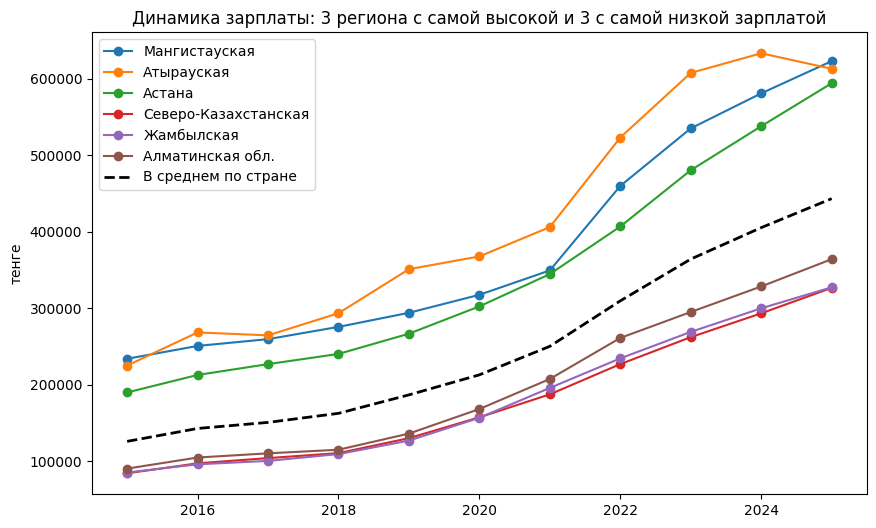

      отношение max/min  разрыв, тенге
2015               2.78       149683.0
2016               2.79       172397.0
2017               2.63       164061.0
2018               2.68       184151.0
2019               2.76       224059.0
2020               2.34       210953.0
2021               2.17       218665.0
2022               2.30       296188.0
2023               2.32       345388.0
2024               2.16       339901.0
2025               1.91       296380.0
Рост по стране, раз: 3.52


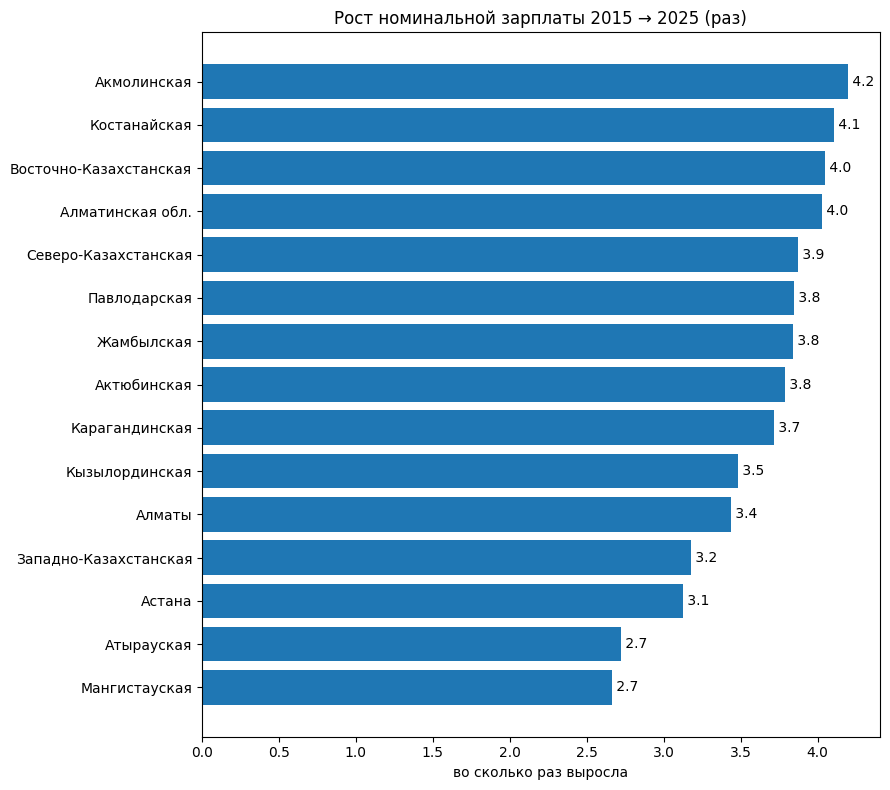

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Читаем файл и находим строку с годами
raw = pd.read_excel("СЗП_рег по составу ФЗП русс.xlsx", header=None)
year_row = raw.index[pd.to_numeric(raw[1], errors="coerce") == 2015][0]
years_found = raw.iloc[year_row, 1:12].tolist()

# 2. Собираем первый блок таблицы
block = raw.iloc[year_row + 1:, 0:12].copy()
block.columns = ["region"] + [int(y) for y in years_found]
block = block.dropna(subset=["region"])

for col in block.columns[1:]:
    block[col] = pd.to_numeric(block[col], errors="coerce")

# 3. Убираем сноски и приводим названия в порядок
block = block[~block["region"].str.contains(r"^\s*\d\)", regex=True, na=False)].copy()
block["region"] = (block["region"]
                   .str.replace("г. ", "", regex=False)
                   .str.replace("- ", "-", regex=False)
                   .str.strip())

# 4. Отделяем итог по стране от регионов
kz = block[block["region"] == "Республика Казахстан"]
regions = block[block["region"] != "Республика Казахстан"]

# 5. Оставляем регионы с полным рядом 2015-2025
years = list(range(2015, 2026))
full = regions.dropna(subset=years).copy()
full["region"] = full["region"].replace({"Алматинская": "Алматинская обл."})
print("Регионов с полным рядом данных:", len(full))

# 6. График 1: динамика самых богатых и самых бедных регионов
top = full.nlargest(3, 2025)["region"].tolist()
bottom = full.nsmallest(3, 2025)["region"].tolist()
tbl = full.set_index("region")[years]

plt.figure(figsize=(10, 6))
for name, row in tbl.loc[top + bottom].iterrows():
    plt.plot(years, row.values, marker="o", label=name)
plt.plot(years, kz.set_index("region")[years].iloc[0].values,
         "k--", linewidth=2, label="В среднем по стране")
plt.title("Динамика зарплаты: 3 региона с самой высокой и 3 с самой низкой зарплатой")
plt.ylabel("тенге")
plt.legend()
plt.savefig("chart1_dynamics.png", dpi=150, bbox_inches="tight")
plt.show()

# 7. Точные числа для выводов
ratio = (full[years].max() / full[years].min()).round(2)
gap = (full[years].max() - full[years].min()).round(0)
print(pd.DataFrame({"отношение max/min": ratio, "разрыв, тенге": gap}))
print("Рост по стране, раз:", round(kz[2025].iloc[0] / kz[2015].iloc[0], 2))

# 8. График 2: во сколько раз выросла зарплата с 2015 по 2025
full["рост_раз"] = full[2025] / full[2015]
growth = full.sort_values("рост_раз")

plt.figure(figsize=(9, 8))
plt.barh(growth["region"], growth["рост_раз"])
for i, v in enumerate(growth["рост_раз"]):
    plt.text(v, i, f" {v:.1f}", va="center")
plt.title("Рост номинальной зарплаты 2015 → 2025 (раз)")
plt.xlabel("во сколько раз выросла")
plt.tight_layout()
plt.savefig("chart2_growth.png", dpi=150, bbox_inches="tight")
plt.show()

# 9. Сохраняем очищенную таблицу
full.drop(columns="рост_раз").to_csv("clean_regions_2015_2025.csv", index=False)